In [29]:
#!pip install neuralforecast
#!pip install matplotlib
#!pip install -U ipywidgets

In [30]:
import pandas as pd

In [31]:
#!dvc init

In [32]:
#!dvc remote add -d yandexstorage s3://ml-datasets01/dvc-storage

In [33]:
!dvc pull

Fetching
!
  0% Checking cache in '/home/olga/ML/Projects/HW/homework-test/hw5_nl/.dvc/cach
Fetching                                                                        
Building workspace index                              |6.00 [00:00,  319entry/s]
Comparing indexes                                    |7.00 [00:00, 1.34kentry/s]
Applying changes                                      |0.00 [00:00,     ?file/s]
Everything is up to date.


In [34]:
Y_df = pd.read_csv('DATA/SBER/hour.csv')
Y_df = Y_df.rename(columns={'time': 'ds'})
Y_df['ds'] = pd.to_datetime(Y_df['ds'])
Y_df['unique_id'] = 1  # Все данные одного актива
Y_df['y'] = Y_df['close']  # Прогнозируем цену закрытия


In [35]:
Y_df.head()

,Unnamed: 0,ds,open,high,low,close,volume,unique_id,y
0,0,2018-03-07 18:00:00+00:00,273.16,273.30,272.18,272.31,285385,1,272.31
1,1,2018-03-07 19:00:00+00:00,272.25,272.75,270.39,270.81,551439,1,270.81
2,2,2018-03-07 20:00:00+00:00,270.71,272.59,270.53,271.70,400328,1,271.70
3,3,2018-03-07 21:00:00+00:00,271.61,272.70,271.21,271.42,253518,1,271.42
4,4,2018-03-07 22:00:00+00:00,271.42,271.75,270.15,271.05,264009,1,271.05


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

from neuralforecast import NeuralForecast
from neuralforecast.models import TSMixerx
from neuralforecast.losses.pytorch import MAE, MQLoss

In [37]:
test_size = 24
horizon = test_size
Y_train_df = Y_df.iloc[:-test_size]
Y_test_df = Y_df.iloc[-test_size:]

model = TSMixerx(h=horizon,
                input_size=horizon*2,
                n_series=1, 
				hist_exog_list=['open', 'high', 'low', 'volume'],
                n_block=6,
                #ff_dim=4,
                dropout=0.1,
                revin=True,
                scaler_type='robust',
                max_steps=500,
                early_stop_patience_steps=-1,
                val_check_steps=5,
                learning_rate=1e-3,
                loss=MQLoss(),
                batch_size=32,
				random_seed=777,
                )

Seed set to 777


In [38]:
fcst = NeuralForecast(models=[model], freq='h')
fcst.fit(df=Y_train_df, val_size=horizon)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MQLoss            | 5      | train
1 | padder_train        | ConstantPad1d     | 0      | train
2 | scaler              | TemporalNorm      | 0      | train
3 | norm                | RevINMultivariate | 2      | train
4 | temporal_projection | Linear            | 1.2 K  | train
5 | feature_mixer_hist  | FeatureMixing     | 8.0 K  | train
6 | first_mixing        | MixingLayer       | 15.1 K | train
7 | mixing_block        | Sequential        | 90.4 K | train
8 | out                 | Linear            | 325    | train
------------------------------------------------------------------
114 K     Trainable params
5         Non-trainable params
114 K     Total params
0.460     Total 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.


In [39]:
future_df=fcst.make_future_dataframe()
future_df['open']=0
future_df['low']=0
future_df['high']=0
future_df['volume']=0
future_df

,unique_id,ds,open,low,high,volume
0,1,2025-02-28 19:00:00+00:00,0,0,0,0
1,1,2025-02-28 20:00:00+00:00,0,0,0,0
2,1,2025-02-28 21:00:00+00:00,0,0,0,0
3,1,2025-02-28 22:00:00+00:00,0,0,0,0
4,1,2025-02-28 23:00:00+00:00,0,0,0,0
5,1,2025-03-01 00:00:00+00:00,0,0,0,0
6,1,2025-03-01 01:00:00+00:00,0,0,0,0
7,1,2025-03-01 02:00:00+00:00,0,0,0,0
8,1,2025-03-01 03:00:00+00:00,0,0,0,0
9,1,2025-03-01 04:00:00+00:00,0,0,0,0


In [40]:
forecasts = fcst.predict(futr_df=future_df)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [41]:
forecasts

,unique_id,ds,TSMixerx-median,TSMixerx-lo-90,TSMixerx-lo-80,TSMixerx-hi-80,TSMixerx-hi-90
0,1,2025-02-28 19:00:00+00:00,308.104706,304.961060,305.858826,310.255646,311.063416
1,1,2025-02-28 20:00:00+00:00,308.253418,304.896454,306.022827,310.520477,311.544464
2,1,2025-02-28 21:00:00+00:00,308.174561,303.948730,305.350159,310.775635,311.958099
3,1,2025-02-28 22:00:00+00:00,308.476807,303.588806,305.399048,311.485748,313.057617
4,1,2025-02-28 23:00:00+00:00,307.975250,301.796478,303.730164,311.736450,313.170349
5,1,2025-03-01 00:00:00+00:00,308.315582,301.947815,304.320160,311.904663,313.546173
6,1,2025-03-01 01:00:00+00:00,308.074829,301.304626,303.500153,312.045471,313.785461
7,1,2025-03-01 02:00:00+00:00,308.311615,300.670593,303.938202,312.231018,314.468445
8,1,2025-03-01 03:00:00+00:00,308.512299,301.117493,303.623291,313.678589,315.755707
9,1,2025-03-01 04:00:00+00:00,308.324738,300.250854,303.155029,313.441345,315.601776


In [42]:
from utilsforecast.plotting import plot_series
plot_series(Y_df, forecasts, plot_random=False, max_insample_length=48 * 3, engine='plotly')

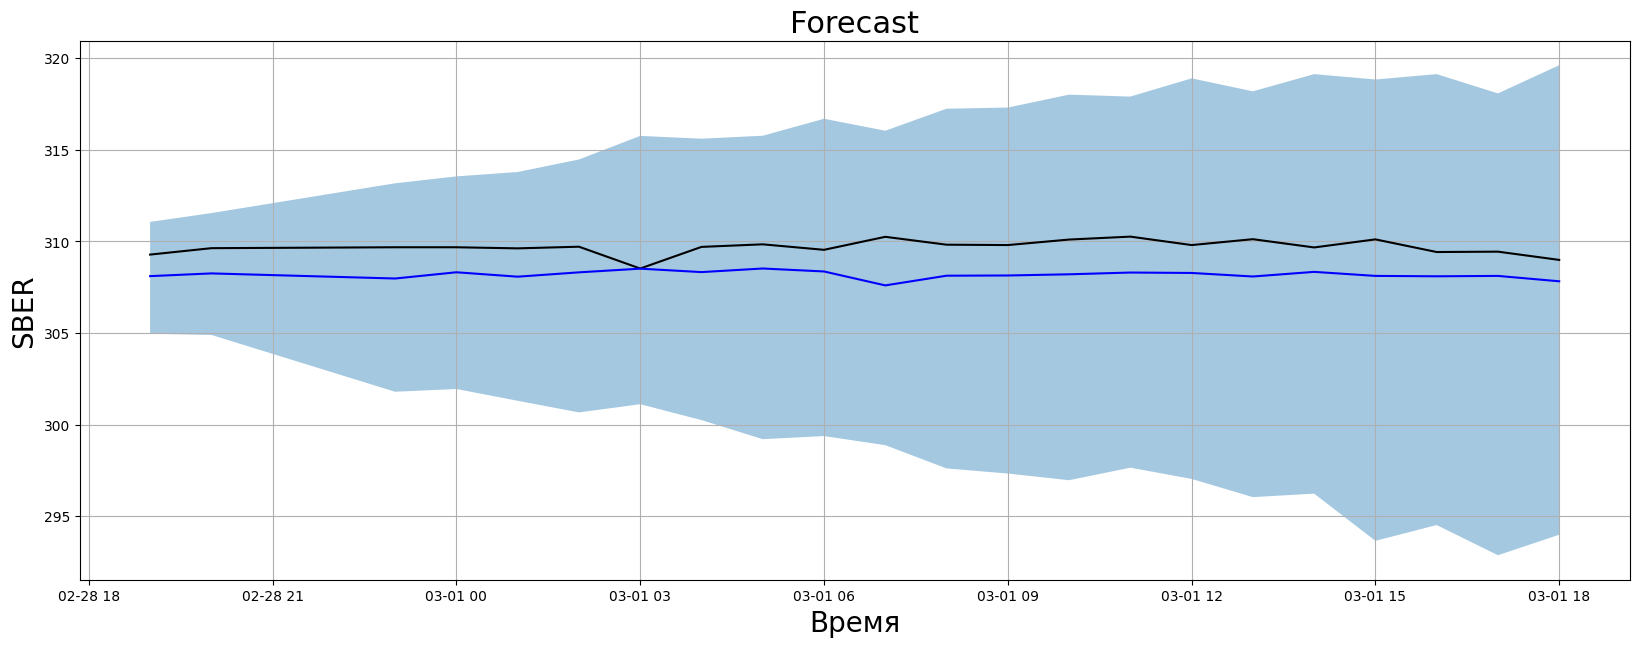

In [47]:
fig, ax = plt.subplots(1, 1, figsize = (20, 7))

plot_df = pd.merge(forecasts, Y_test_df, on='ds', how='inner')


plt.plot(plot_df['ds'], plot_df['y'], c='black', label='True')
plt.plot(plot_df['ds'], plot_df['TSMixerx-median'], c='blue', label='median')
plt.fill_between(x=plot_df['ds'][-horizon:], 
                 y1=plot_df['TSMixerx-lo-90'][-horizon:].values,
                 y2=plot_df['TSMixerx-hi-90'][-horizon:].values,
                 alpha=0.4, label='level 90')
ax.set_title('Forecast', fontsize=22)
ax.set_ylabel('SBER', fontsize=20)
ax.set_xlabel('Время', fontsize=20)
ax.grid()

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [45]:
mse = mean_squared_error(Y_test_df['y'], forecasts.head(horizon)['TSMixerx-median'])
mae = mean_absolute_error(Y_test_df['y'], forecasts.head(horizon)['TSMixerx-median'].head(horizon))
print(mse, mae)

2.3279081701412863 1.474870096842449


In [54]:
cv_results = fcst.cross_validation(
    df=Y_df,
    val_size=horizon,
   # test_size=24,
    n_windows=10,
	refit=True   #Cross-validation with refit
)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MQLoss            | 5      | train
1 | padder_train        | ConstantPad1d     | 0      | train
2 | scaler              | TemporalNorm      | 0      | train
3 | norm                | RevINMultivariate | 2      | train
4 | temporal_projection | Linear            | 1.2 K  | train
5 | feature_mixer_hist  | FeatureMixing     | 8.0 K  | train
6 | first_mixing        | MixingLayer       | 15.1 K | train
7 | mixing_block        | Sequential        | 90.4 K | train
8 | out                 | Linear            | 325    | train
------------------------------------------------------------------
114 K     Trainable params
5         Non-trainable params
114 K     Total params
0.460     Total 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [50]:
cv_results

,unique_id,ds,cutoff,TSMixerx-median,TSMixerx-lo-90,TSMixerx-lo-80,TSMixerx-hi-80,TSMixerx-hi-90,y
0,1,2025-02-28 20:00:00+00:00,2025-02-28 19:00:00+00:00,308.854095,306.892731,307.295410,310.054749,310.599762,309.63
1,1,2025-02-28 23:00:00+00:00,2025-02-28 19:00:00+00:00,308.864624,305.883820,306.788208,310.481964,311.192261,309.68
2,1,2025-03-01 00:00:00+00:00,2025-02-28 19:00:00+00:00,308.349670,304.751678,305.899689,310.369568,311.528961,309.68
3,1,2025-03-01 01:00:00+00:00,2025-02-28 19:00:00+00:00,308.831207,304.847412,306.151886,310.995148,312.102631,309.62
4,1,2025-03-01 02:00:00+00:00,2025-02-28 19:00:00+00:00,308.940216,304.571808,305.996582,311.353424,312.609528,309.71
5,1,2025-03-01 03:00:00+00:00,2025-02-28 19:00:00+00:00,308.925751,303.938324,305.855896,311.336029,312.734406,308.52
6,1,2025-03-01 04:00:00+00:00,2025-02-28 19:00:00+00:00,308.886871,303.253357,305.246490,311.738068,313.404175,309.70
7,1,2025-03-01 05:00:00+00:00,2025-02-28 19:00:00+00:00,308.630280,302.653778,304.745392,311.986145,313.555084,309.84
8,1,2025-03-01 06:00:00+00:00,2025-02-28 19:00:00+00:00,308.753082,302.508057,304.676300,311.938263,313.297424,309.54
9,1,2025-03-01 07:00:00+00:00,2025-02-28 19:00:00+00:00,308.893097,302.428314,304.637115,312.490509,314.468658,310.25


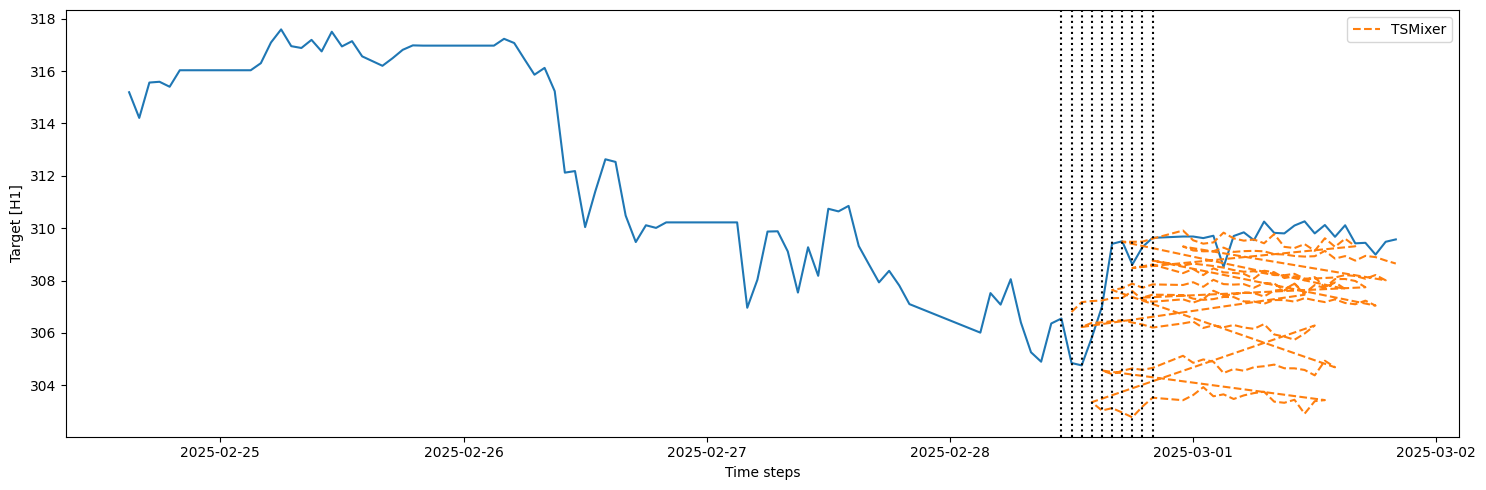

In [56]:
cutoffs = cv_results['cutoff'].unique()

lastY=Y_df.tail(100)

plt.figure(figsize=(15,5))
plt.plot(lastY['ds'], lastY['y'])
plt.plot(cv_results['ds'], cv_results['TSMixerx-median'], label='TSMixer', ls='--')

for cutoff in cutoffs:
    plt.axvline(x=cutoff, color='black', ls=':')

plt.xlabel('Time steps')
plt.ylabel('Target [H1]')
plt.legend()
plt.tight_layout()

In [ ]:

metrics = []
for window in cutoffs:

	y_true = cv_results['y'].loc[cv_results['cutoff']==window].values
	y_pred = cv_results['TSMixerx-median'].loc[cv_results['cutoff']==window].values 
    
	mse = mean_squared_error(y_true, y_pred)
	mae = mean_absolute_error(y_true, y_pred)
	metrics.append({'MSE': mse, 'MAE': mae})

# Усреднение метрик
avg_metrics = pd.DataFrame(metrics).mean()
print(f'Average MSE: {avg_metrics["MSE"]:.4f}, Average MAE: {avg_metrics["MAE"]:.4f}')

Average MSE: 9.0537, Average MAE: 2.4186
